# OCTA - ResNet18 | 3 S?n?fl? S?n?fland?rma

Bu notebook mevcut pipeline'? bozmadan ResNet18 ile 3 s?n?fl? g?z hastal??? s?n?fland?rmas? yapar: **NORMAL / DR / AMD**.

Ana prensipler:
- Ayn? `split_3sinif.json` kullan?l?r; modeller aras? kar??la?t?rma adil kal?r.
- Split hasta bazl?d?r; ayn? hasta train/val/test aras?nda kar??maz.
- Model g?r?nt? baz?nda e?itilir.
- Sonu?lar hem g?r?nt? bazl? hem hasta bazl? raporlan?r.
- Hasta bazl? karar i?in softmax olas?l?k ortalamas? kullan?l?r.


In [1]:
# -- HUCRE 1: Kutuphaneler, Seed ve Focal Loss ------------------------------
import os, random, warnings, json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

warnings.filterwarnings('ignore')

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.alpha = torch.tensor(alpha, dtype=torch.float32) if alpha is not None else None

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            alpha_t = alpha.gather(0, targets.view(-1))
            focal_loss = alpha_t * focal_loss
        if self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss.mean()

print('Kutuphaneler ve FocalLoss hazir.')


Kutuphaneler ve FocalLoss hazir.


In [2]:
# -- HUCRE 2: Cihaz ve Sabitler -------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('UYARI: CPU kullaniliyor; egitim yavas olabilir.')

OCTA_DIR   = Path(r'C:\users\yunus\desktop\bitirmep\data\OCTA')
EXCEL_PATH = Path(r'C:\users\yunus\desktop\bitirmep\data\Textlabels.xlsx')
SPLIT_PATH = Path(r'C:\users\yunus\desktop\bitirmep\data\split_3sinif.json')
SAVE_DIR   = Path(r'C:\users\yunus\desktop\bitirmep\outputs\resnet18_3sinif_final')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['NORMAL', 'DR', 'AMD']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_EPOCHS  = 35
MAX_LR      = 8e-4
VAL_SIZE    = 0.15
TEST_SIZE   = 0.20
SEED        = 42
PATIENCE    = 10
FREEZE_EPOCHS = 2
MIXUP_ALPHA = 0.2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'Siniflar: {CLASS_NAMES}')
print(f'Cikti klasoru: {SAVE_DIR}')


GPU: NVIDIA GeForce GTX 1650
Siniflar: ['NORMAL', 'DR', 'AMD']
Cikti klasoru: C:\users\yunus\desktop\bitirmep\outputs\resnet18_3sinif_final


In [3]:
# -- HUCRE 3: Veri Yukleme ve CNV Filtreleme -------------------------------
df = pd.read_excel(EXCEL_PATH)
df.columns = df.columns.str.strip()
df['ID'] = df['ID'].astype(str)

df = df[df['Disease'].isin(CLASS_NAMES)].reset_index(drop=True)
label_map = {name: i for i, name in enumerate(CLASS_NAMES)}
df['label'] = df['Disease'].map(label_map)

print(f'CNV cikarildi -> kalan hasta: {len(df)}')
print(df['Disease'].value_counts())

exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
records = []
for _, row in df.iterrows():
    patient_dir = OCTA_DIR / str(row['ID'])
    if not patient_dir.exists():
        continue
    for img_file in patient_dir.iterdir():
        if img_file.suffix.lower() in exts:
            records.append({
                'img_path': str(img_file),
                'label': int(row['label']),
                'disease': row['Disease'],
                'patient_id': row['ID'],
            })

img_df = pd.DataFrame(records)
print(f'\nToplam goruntu: {len(img_df)}')
print(f'Toplam hasta  : {img_df["patient_id"].nunique()}')
print(img_df['disease'].value_counts())


CNV cikarildi -> kalan hasta: 195
Disease
NORMAL    160
DR         29
AMD         6
Name: count, dtype: int64

Toplam goruntu: 59280
Toplam hasta  : 195
disease
NORMAL    48640
DR         8816
AMD        1824
Name: count, dtype: int64


In [5]:
# -- HUCRE 4: Hasta Bazli Split - JSON'dan Yukle ---------------------------
if SPLIT_PATH.exists():
    with open(SPLIT_PATH, 'r', encoding='utf-8') as f:
        split = json.load(f)
    train_ids = list(map(str, split['train']))
    val_ids   = list(map(str, split['val']))
    test_ids  = list(map(str, split['test']))
    print(f'Split JSON yuklendi: {SPLIT_PATH}')
else:
    print('UYARI: Split JSON bulunamadi, yeni hasta bazli split olusturuluyor.')
    patient_ids = img_df['patient_id'].unique()
    patient_labels = (
        img_df.drop_duplicates('patient_id')
              .set_index('patient_id')
              .loc[patient_ids, 'label']
    )
    train_val_ids, test_ids = train_test_split(
        patient_ids, test_size=TEST_SIZE,
        stratify=patient_labels, random_state=SEED
    )
    train_val_labels = (
        img_df.drop_duplicates('patient_id')
              .set_index('patient_id')
              .loc[train_val_ids, 'label']
    )
    train_ids, val_ids = train_test_split(
        train_val_ids, test_size=VAL_SIZE,
        stratify=train_val_labels, random_state=SEED
    )
    split = {'train': list(map(str, train_ids)), 'val': list(map(str, val_ids)), 'test': list(map(str, test_ids))}
    with open(SPLIT_PATH, 'w', encoding='utf-8') as f:
        json.dump(split, f, indent=2)
    print(f'Yeni split kaydedildi: {SPLIT_PATH}')

train_df = img_df[img_df['patient_id'].isin(train_ids)].reset_index(drop=True)
val_df   = img_df[img_df['patient_id'].isin(val_ids)].reset_index(drop=True)
test_df  = img_df[img_df['patient_id'].isin(test_ids)].reset_index(drop=True)

print(f'Train: {len(train_df):>6} goruntu | {len(train_ids)} hasta')
print(f'Val  : {len(val_df):>6} goruntu | {len(val_ids)} hasta')
print(f'Test : {len(test_df):>6} goruntu | {len(test_ids)} hasta')

for name, part in [('TRAIN', train_df), ('VAL', val_df), ('TEST', test_df)]:
    patient_counts = part.drop_duplicates('patient_id')['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    image_counts = part['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    print(f'\n{name} hasta dagilimi:')
    print(patient_counts)
    print(f'{name} goruntu dagilimi:')
    print(image_counts)

assert set(train_ids).isdisjoint(val_ids)
assert set(train_ids).isdisjoint(test_ids)
assert set(val_ids).isdisjoint(test_ids)
print('\nHasta sizintisi yok: train/val/test hasta ID kesisimleri 0.')


Split JSON yuklendi: C:\users\yunus\desktop\bitirmep\data\split_3sinif.json
Train:  40128 goruntu | 132 hasta
Val  :   7296 goruntu | 24 hasta
Test :  11856 goruntu | 39 hasta

TRAIN hasta dagilimi:
disease
NORMAL    108
DR         20
AMD         4
Name: count, dtype: int64
TRAIN goruntu dagilimi:
disease
NORMAL    32832
DR         6080
AMD        1216
Name: count, dtype: int64

VAL hasta dagilimi:
disease
NORMAL    20
DR         3
AMD        1
Name: count, dtype: int64
VAL goruntu dagilimi:
disease
NORMAL    6080
DR         912
AMD        304
Name: count, dtype: int64

TEST hasta dagilimi:
disease
NORMAL    32
DR         6
AMD        1
Name: count, dtype: int64
TEST goruntu dagilimi:
disease
NORMAL    9728
DR        1824
AMD        304
Name: count, dtype: int64

Hasta sizintisi yok: train/val/test hasta ID kesisimleri 0.


In [6]:
# -- HUCRE 5: Augmentation, Dataset ve Weighted Sampler ---------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.25),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.18, contrast=0.18, saturation=0.06),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.08, scale=(0.02, 0.08)),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class EyeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        if isinstance(image, torch.Tensor) and image.shape[0] > 3:
            image = image[:3, :, :]
        return image, int(row['label'])

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

label_counts = train_df['label'].value_counts().sort_index().values.astype(np.float32)
class_weights = len(train_df) / (NUM_CLASSES * label_counts)
class_weights[1] *= 1.35  # DR duyarliligini artirmak icin
class_weights[2] *= 1.15  # AMD az hasta oldugu icin kontrollu agirlik

print('Sinif agirliklari:')
for name, w in zip(CLASS_NAMES, class_weights):
    print(f'  {name}: {w:.3f}')

train_dataset = EyeDataset(train_df, transform=train_transform)
val_dataset   = EyeDataset(val_df,   transform=val_test_transform)
test_dataset  = EyeDataset(test_df,  transform=val_test_transform)

sample_weights = train_df['label'].map({i: class_weights[i] for i in range(NUM_CLASSES)}).values
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

pin = (device.type == 'cuda')
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)

print('DataLoader, WeightedRandomSampler ve MixUp hazir.')


Sinif agirliklari:
  NORMAL: 0.407
  DR: 2.970
  AMD: 12.650
DataLoader, WeightedRandomSampler ve MixUp hazir.


In [7]:
# -- HUCRE 6: ResNet18 Model, Loss, Optimizer ------------------------------
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.35),
    nn.Linear(num_features, 256),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(256),
    nn.Dropout(p=0.20),
    nn.Linear(256, NUM_CLASSES),
)
model = model.to(device)

label_smoothing_loss = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(device),
    label_smoothing=0.08,
)
focal_criterion = FocalLoss(alpha=class_weights, gamma=1.8)

def combined_loss(outputs, labels):
    return 0.65 * focal_criterion(outputs, labels) + 0.35 * label_smoothing_loss(outputs, labels)

def freeze_backbone(m):
    for name, param in m.named_parameters():
        if not name.startswith('fc.'):
            param.requires_grad = False

def unfreeze_backbone(m):
    for param in m.parameters():
        param.requires_grad = True

freeze_backbone(model)

backbone_params = [p for n, p in model.named_parameters() if not n.startswith('fc.')]
head_params = list(model.fc.parameters())

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': MAX_LR / 20},
    {'params': head_params,     'lr': MAX_LR},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[MAX_LR / 20, MAX_LR],
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.18,
    anneal_strategy='cos',
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
CHECKPOINT = SAVE_DIR / 'resnet18_3sinif_best_macrof1.pth'

print(f'Toplam parametre  : {total_params:,}')
print(f'Egitilebilir param: {trainable_params:,} (ilk {FREEZE_EPOCHS} epoch backbone donuk)')
print(f'Checkpoint        : {CHECKPOINT}')


Toplam parametre  : 11,309,123
Egitilebilir param: 132,611 (ilk 2 epoch backbone donuk)
Checkpoint        : C:\users\yunus\desktop\bitirmep\outputs\resnet18_3sinif_final\resnet18_3sinif_best_macrof1.pth


In [8]:
# -- HUCRE 7: Egitim Dongusu - Macro F1 Odakli -----------------------------
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_macro_f1': [],
    'val_bal_acc': [],
    'val_dr_recall': [],
}

best_score = -1.0
best_val_loss = float('inf')
patience_counter = 0

def evaluate_loader(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    preds_all, labels_all = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = combined_loss(outputs, labels)
            preds = outputs.argmax(1)

            total_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += images.size(0)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    avg_loss = total_loss / total
    acc = correct / total * 100
    macro_f1 = f1_score(labels_all, preds_all, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(labels_all, preds_all)
    dr_recall = recall_score(labels_all, preds_all, labels=[1], average=None, zero_division=0)[0]
    return avg_loss, acc, macro_f1, bal_acc, dr_recall

print('EGITIM BASLIYOR...')
print(f'{"Epoch":>5} | {"TrLoss":>8} | {"TrAcc":>7} | {"ValLoss":>8} | {"ValAcc":>7} | {"MacroF1":>8} | {"BalAcc":>7} | Durum')
print('-' * 105)

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        unfreeze_backbone(model)
        print(f'  Epoch {epoch}: backbone acildi, fine-tuning basliyor.')

    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    counted_total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        use_mixup = (np.random.rand() < 0.35)
        if use_mixup:
            images_m, labels_a, labels_b, lam = mixup_data(images, labels, alpha=MIXUP_ALPHA)
            outputs = model(images_m)
            loss = mixup_criterion(combined_loss, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(images)
            loss = combined_loss(outputs, labels)
            tr_correct += (outputs.argmax(1) == labels).sum().item()
            counted_total += images.size(0)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        tr_loss += loss.item() * images.size(0)
        tr_total += images.size(0)

        if (batch_idx + 1) % max(1, len(train_loader) // 3) == 0:
            sys.stdout.write(f'\r  Epoch {epoch:02d} batch {batch_idx+1}/{len(train_loader)} | loss {tr_loss/tr_total:.4f}')
            sys.stdout.flush()

    sys.stdout.write('\r' + ' ' * 80 + '\r')
    epoch_tr_loss = tr_loss / tr_total
    epoch_tr_acc = (tr_correct / counted_total * 100) if counted_total > 0 else 0.0

    epoch_vl_loss, epoch_vl_acc, epoch_macro_f1, epoch_bal_acc, epoch_dr_recall = evaluate_loader(val_loader)

    history['train_loss'].append(epoch_tr_loss)
    history['val_loss'].append(epoch_vl_loss)
    history['train_acc'].append(epoch_tr_acc)
    history['val_acc'].append(epoch_vl_acc)
    history['val_macro_f1'].append(epoch_macro_f1)
    history['val_bal_acc'].append(epoch_bal_acc)
    history['val_dr_recall'].append(epoch_dr_recall)

    # Macro-F1 ana kriter; balanced accuracy ve DR recall kucuk destek verir.
    score = epoch_macro_f1 + 0.10 * epoch_bal_acc + 0.05 * epoch_dr_recall
    improved = score > best_score or (np.isclose(score, best_score) and epoch_vl_loss < best_val_loss)

    status = ''
    if improved:
        best_score = score
        best_val_loss = epoch_vl_loss
        torch.save(model.state_dict(), CHECKPOINT)
        patience_counter = 0
        status = 'BEST'
    else:
        patience_counter += 1
        status = f'wait {patience_counter}/{PATIENCE}'

    print(f'{epoch:5d} | {epoch_tr_loss:8.4f} | {epoch_tr_acc:6.2f}% | {epoch_vl_loss:8.4f} | {epoch_vl_acc:6.2f}% | {epoch_macro_f1:8.4f} | {epoch_bal_acc:7.4f} | {status}')

    if patience_counter >= PATIENCE:
        print(f'Erken durdurma: {PATIENCE} epoch iyilesme yok.')
        break

print(f'\nEn iyi model kaydedildi: {CHECKPOINT}')


EGITIM BASLIYOR...
Epoch |   TrLoss |   TrAcc |  ValLoss |  ValAcc |  MacroF1 |  BalAcc | Durum
---------------------------------------------------------------------------------------------------------
    1 |   1.5418 |  50.72% |   1.1034 |  18.50% |   0.2601 |  0.5573 | BEST     
    2 |   0.9223 |  52.34% |   1.2887 |  16.45% |   0.2712 |  0.5503 | BEST     
  Epoch 3: backbone acildi, fine-tuning basliyor.
    3 |   0.5045 |  75.77% |   1.0551 |  69.37% |   0.5580 |  0.7181 | BEST     
    4 |   0.3727 |  86.53% |   1.0988 |  71.98% |   0.5368 |  0.6528 | wait 1/10
    5 |   0.3252 |  89.95% |   1.3130 |  78.45% |   0.5404 |  0.6074 | wait 2/10
    6 |   0.2709 |  92.86% |   1.0746 |  62.66% |   0.4935 |  0.6971 | wait 3/10
    7 |   0.2344 |  94.06% |   0.9413 |  82.15% |   0.5932 |  0.6269 | BEST     
    8 |   0.2160 |  95.48% |   0.9299 |  81.30% |   0.6135 |  0.6719 | BEST     
    9 |   0.2028 |  96.30% |   0.9236 |  77.08% |   0.5966 |  0.6872 | wait 1/10
   10 |   0.1911 | 

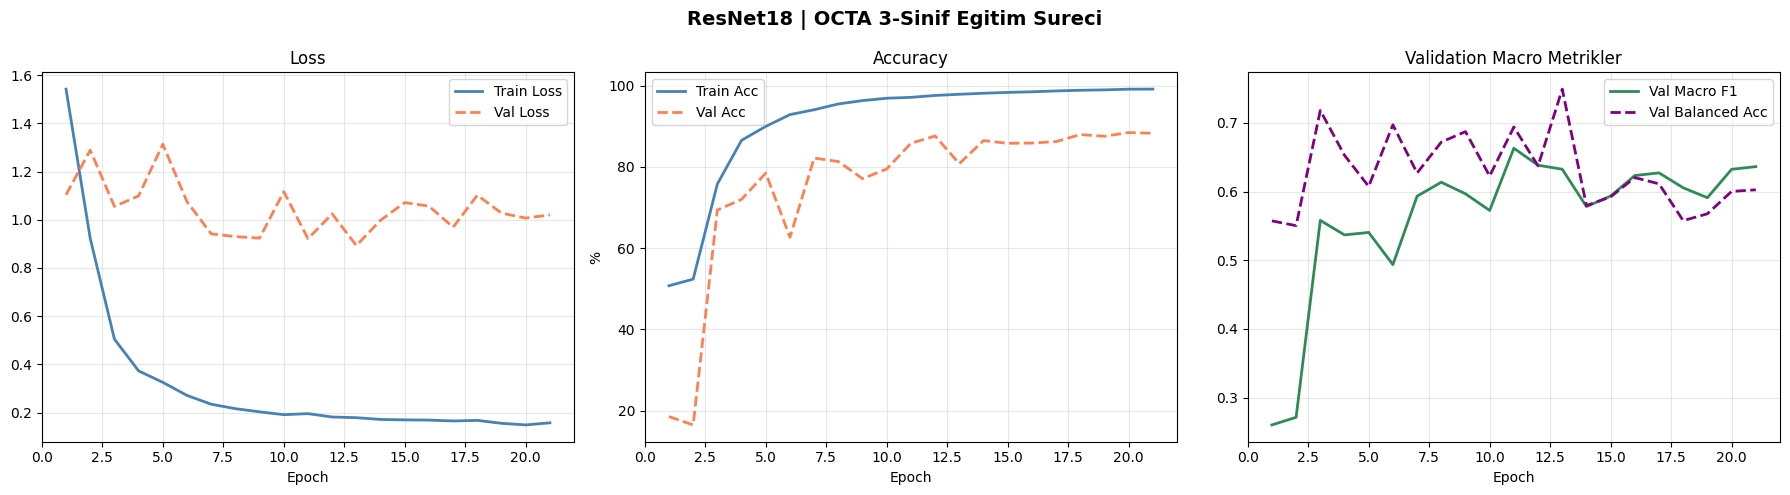

Grafik kaydedildi: C:\users\yunus\desktop\bitirmep\outputs\resnet18_3sinif_final\resnet18_training_curves.png


In [9]:
# -- HUCRE 8: Egitim Grafikleri -------------------------------------------
actual_epochs = len(history['train_loss'])
epochs_x = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ResNet18 | OCTA 3-Sinif Egitim Sureci', fontsize=14, fontweight='bold')

axes[0].plot(epochs_x, history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs_x, history['val_loss'], label='Val Loss', color='coral', linestyle='--', linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_x, history['train_acc'], label='Train Acc', color='steelblue', linewidth=2)
axes[1].plot(epochs_x, history['val_acc'], label='Val Acc', color='coral', linestyle='--', linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(epochs_x, history['val_macro_f1'], label='Val Macro F1', color='seagreen', linewidth=2)
axes[2].plot(epochs_x, history['val_bal_acc'], label='Val Balanced Acc', color='purple', linestyle='--', linewidth=2)
axes[2].set_title('Validation Macro Metrikler')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / 'resnet18_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik kaydedildi:', SAVE_DIR / 'resnet18_training_curves.png')


In [10]:
# -- HUCRE 9: TTA ile Olasilik Uretimi ------------------------------------
tta_transforms = [
    val_test_transform,
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(8, 8)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
]

model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()

def get_tta_probs(dataframe):
    all_probs_list = []
    labels_out = None
    patient_ids_out = None
    with torch.no_grad():
        for tfm in tta_transforms:
            dataset = EyeDataset(dataframe, transform=tfm)
            loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == 'cuda'))
            probs, labels = [], []
            for images, batch_labels in loader:
                images = images.to(device)
                outputs = F.softmax(model(images), dim=1)
                probs.extend(outputs.cpu().numpy())
                labels.extend(batch_labels.numpy())
            all_probs_list.append(np.array(probs))
            labels_out = np.array(labels)
            patient_ids_out = dataframe.reset_index(drop=True)['patient_id'].values
    return np.mean(all_probs_list, axis=0), labels_out, patient_ids_out

print('Validation ve test setleri icin TTA olasiliklari hesaplaniyor...')
val_probs, val_labels, val_patient_ids = get_tta_probs(val_df)
test_probs, test_labels, test_patient_ids = get_tta_probs(test_df)
print('TTA tamamlandi.')


Validation ve test setleri icin TTA olasiliklari hesaplaniyor...
TTA tamamlandi.


In [11]:
# -- HUCRE 10: Goruntu Bazli Degerlendirme --------------------------------
def threshold_predict(probs, thresholds):
    preds = []
    for p in probs:
        # AMD ve DR oncelikli kontrol edilir; hicbiri gecmezse NORMAL.
        if p[2] >= thresholds[2]:
            preds.append(2)
        elif p[1] >= thresholds[1]:
            preds.append(1)
        else:
            preds.append(int(np.argmax(p)))
    return np.array(preds)

# Validation uzerinde DR/AMD threshold aramasi; argmax da ayrica raporlanir.
best_img_thresholds = [0.50, 0.50, 0.50]
best_img_macro_f1 = f1_score(val_labels, np.argmax(val_probs, axis=1), average='macro', zero_division=0)

for thr_dr in np.arange(0.25, 0.61, 0.05):
    for thr_amd in np.arange(0.20, 0.61, 0.05):
        thresholds = [0.50, float(thr_dr), float(thr_amd)]
        preds = threshold_predict(val_probs, thresholds)
        macro_f1 = f1_score(val_labels, preds, average='macro', zero_division=0)
        if macro_f1 > best_img_macro_f1:
            best_img_macro_f1 = macro_f1
            best_img_thresholds = thresholds

img_preds_argmax = np.argmax(test_probs, axis=1)
img_preds_thr = threshold_predict(test_probs, best_img_thresholds)

print('GORUNTU BAZLI RAPOR - ARGMAX')
print('=' * 70)
print(classification_report(test_labels, img_preds_argmax, target_names=CLASS_NAMES, digits=4))
print(f'Balanced Accuracy: {balanced_accuracy_score(test_labels, img_preds_argmax):.4f}')

print('\nGORUNTU BAZLI RAPOR - THRESHOLD')
print('=' * 70)
print(f'Val ile secilen thresholdlar: NORMAL={best_img_thresholds[0]:.2f}, DR={best_img_thresholds[1]:.2f}, AMD={best_img_thresholds[2]:.2f}')
print(classification_report(test_labels, img_preds_thr, target_names=CLASS_NAMES, digits=4))
print(f'Balanced Accuracy: {balanced_accuracy_score(test_labels, img_preds_thr):.4f}')

labels_bin = label_binarize(test_labels, classes=[0, 1, 2])
try:
    auc = roc_auc_score(labels_bin, test_probs, multi_class='ovr', average='macro')
    print(f'Macro AUC OvR: {auc:.4f}')
except Exception as e:
    print(f'AUC hesaplanamadi: {e}')


GORUNTU BAZLI RAPOR - ARGMAX
              precision    recall  f1-score   support

      NORMAL     0.9341    0.9654    0.9494      9728
          DR     0.9026    0.5992    0.7203      1824
         AMD     0.5144    1.0000    0.6793       304

    accuracy                         0.9099     11856
   macro avg     0.7837    0.8549    0.7830     11856
weighted avg     0.9184    0.9099    0.9073     11856

Balanced Accuracy: 0.8549

GORUNTU BAZLI RAPOR - THRESHOLD
Val ile secilen thresholdlar: NORMAL=0.50, DR=0.40, AMD=0.50
              precision    recall  f1-score   support

      NORMAL     0.9341    0.9654    0.9494      9728
          DR     0.9026    0.5998    0.7207      1824
         AMD     0.5153    1.0000    0.6801       304

    accuracy                         0.9100     11856
   macro avg     0.7840    0.8550    0.7834     11856
weighted avg     0.9185    0.9100    0.9073     11856

Balanced Accuracy: 0.8550
Macro AUC OvR: 0.9143


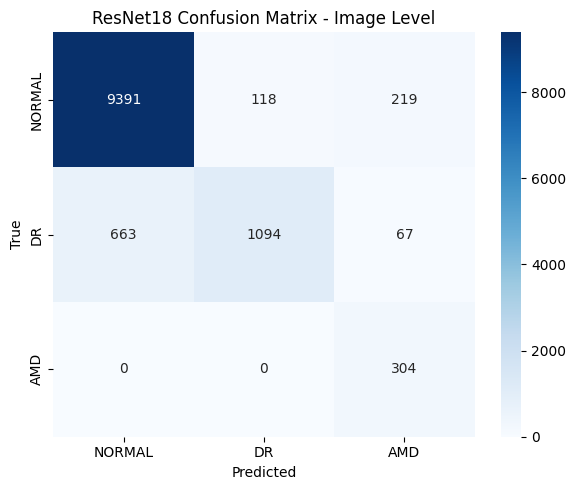

Kaydedildi: C:\users\yunus\desktop\bitirmep\outputs\resnet18_3sinif_final\resnet18_confusion_matrix_image.png


In [12]:
# -- HUCRE 11: Goruntu Bazli Confusion Matrix ------------------------------
cm_img = confusion_matrix(test_labels, img_preds_thr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_img, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ResNet18 Confusion Matrix - Image Level')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'resnet18_confusion_matrix_image.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi:', SAVE_DIR / 'resnet18_confusion_matrix_image.png')


HASTA BAZLI RAPOR - ARGMAX
              precision    recall  f1-score   support

      NORMAL     0.9394    0.9688    0.9538        32
          DR     1.0000    0.6667    0.8000         6
         AMD     0.5000    1.0000    0.6667         1

    accuracy                         0.9231        39
   macro avg     0.8131    0.8785    0.8068        39
weighted avg     0.9375    0.9231    0.9228        39

Patient Balanced Accuracy: 0.8785

HASTA BAZLI RAPOR - THRESHOLD
Val patient Macro-F1: 0.7730
Val ile secilen thresholdlar: NORMAL=0.50, DR=0.50, AMD=0.50
              precision    recall  f1-score   support

      NORMAL     0.9394    0.9688    0.9538        32
          DR     1.0000    0.6667    0.8000         6
         AMD     0.5000    1.0000    0.6667         1

    accuracy                         0.9231        39
   macro avg     0.8131    0.8785    0.8068        39
weighted avg     0.9375    0.9231    0.9228        39

Patient Balanced Accuracy: 0.8785


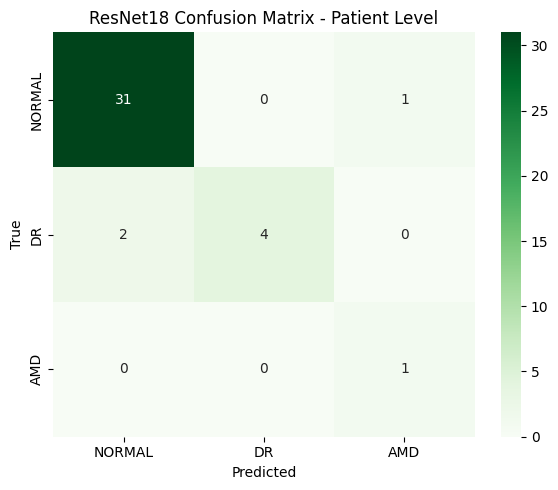


Hasta bazli tahmin tablosu:


,patient_id,disease,image_count,p_normal,p_dr,p_amd,pred_argmax,pred_threshold
0,10303,NORMAL,304,0.516779,0.175356,0.307866,NORMAL,NORMAL
1,10310,AMD,304,0.004916,0.026130,0.968954,AMD,AMD
2,10322,NORMAL,304,0.564021,0.096814,0.339165,NORMAL,NORMAL
3,10324,DR,304,0.551125,0.085550,0.363325,NORMAL,NORMAL
4,10330,NORMAL,304,0.547182,0.128503,0.324315,NORMAL,NORMAL
5,10331,NORMAL,304,0.552269,0.122719,0.325012,NORMAL,NORMAL
6,10350,NORMAL,304,0.593404,0.059975,0.346622,NORMAL,NORMAL
7,10362,NORMAL,304,0.554409,0.118600,0.326991,NORMAL,NORMAL
8,10364,DR,304,0.286901,0.437473,0.275626,DR,DR
9,10365,DR,304,0.407629,0.297716,0.294655,NORMAL,NORMAL


Hasta tahminleri kaydedildi: C:\users\yunus\desktop\bitirmep\outputs\resnet18_3sinif_final\resnet18_patient_predictions.csv


In [13]:
# -- HUCRE 12: Hasta Bazli Degerlendirme -----------------------------------
def patient_level_frame(dataframe, probs):
    probs_df = dataframe.copy().reset_index(drop=True)
    probs_df['p_normal'] = probs[:, 0]
    probs_df['p_dr'] = probs[:, 1]
    probs_df['p_amd'] = probs[:, 2]
    return (
        probs_df.groupby('patient_id')
        .agg({
            'label': 'first',
            'disease': 'first',
            'p_normal': 'mean',
            'p_dr': 'mean',
            'p_amd': 'mean',
            'img_path': 'count',
        })
        .rename(columns={'img_path': 'image_count'})
        .reset_index()
    )

val_patient_df = patient_level_frame(val_df, val_probs)
test_patient_df = patient_level_frame(test_df, test_probs)

val_patient_true = val_patient_df['label'].values
val_patient_probs = val_patient_df[['p_normal', 'p_dr', 'p_amd']].values

def search_patient_thresholds(patient_probs, patient_true):
    best_thresholds = [0.50, 0.50, 0.50]
    best_macro = f1_score(patient_true, np.argmax(patient_probs, axis=1), average='macro', zero_division=0)
    for thr_dr in np.arange(0.25, 0.61, 0.05):
        for thr_amd in np.arange(0.20, 0.61, 0.05):
            thresholds = [0.50, float(thr_dr), float(thr_amd)]
            preds = threshold_predict(patient_probs, thresholds)
            macro = f1_score(patient_true, preds, average='macro', zero_division=0)
            if macro > best_macro:
                best_macro = macro
                best_thresholds = thresholds
    return best_thresholds, best_macro

best_patient_thresholds, best_patient_val_macro = search_patient_thresholds(val_patient_probs, val_patient_true)

test_patient_true = test_patient_df['label'].values
test_patient_probs_arr = test_patient_df[['p_normal', 'p_dr', 'p_amd']].values
patient_preds_argmax = np.argmax(test_patient_probs_arr, axis=1)
patient_preds_thr = threshold_predict(test_patient_probs_arr, best_patient_thresholds)

print('HASTA BAZLI RAPOR - ARGMAX')
print('=' * 70)
print(classification_report(test_patient_true, patient_preds_argmax, target_names=CLASS_NAMES, digits=4))
print(f'Patient Balanced Accuracy: {balanced_accuracy_score(test_patient_true, patient_preds_argmax):.4f}')

print('\nHASTA BAZLI RAPOR - THRESHOLD')
print('=' * 70)
print(f'Val patient Macro-F1: {best_patient_val_macro:.4f}')
print(f'Val ile secilen thresholdlar: NORMAL={best_patient_thresholds[0]:.2f}, DR={best_patient_thresholds[1]:.2f}, AMD={best_patient_thresholds[2]:.2f}')
print(classification_report(test_patient_true, patient_preds_thr, target_names=CLASS_NAMES, digits=4))
print(f'Patient Balanced Accuracy: {balanced_accuracy_score(test_patient_true, patient_preds_thr):.4f}')

cm_patient = confusion_matrix(test_patient_true, patient_preds_thr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ResNet18 Confusion Matrix - Patient Level')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'resnet18_confusion_matrix_patient.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nHasta bazli tahmin tablosu:')
display_cols = ['patient_id', 'disease', 'image_count', 'p_normal', 'p_dr', 'p_amd']
summary_df = test_patient_df[display_cols].copy()
summary_df['pred_argmax'] = [CLASS_NAMES[i] for i in patient_preds_argmax]
summary_df['pred_threshold'] = [CLASS_NAMES[i] for i in patient_preds_thr]
display(summary_df)

summary_df.to_csv(SAVE_DIR / 'resnet18_patient_predictions.csv', index=False)
print('Hasta tahminleri kaydedildi:', SAVE_DIR / 'resnet18_patient_predictions.csv')


In [14]:
# -- HUCRE 13: Rapor Icin Kisa Ozet ---------------------------------------
print('RAPOR OZETI')
print('=' * 70)
print('Model              : ResNet18 ImageNet pretrained')
print('Siniflar           : NORMAL, DR, AMD')
print('Split              : Hasta bazli split_3sinif.json')
print('Egitim             : Goruntu bazli')
print('Nihai degerlendirme: Goruntu bazli + hasta bazli')
print('Hasta karari       : Hasta icindeki goruntulerin softmax olasilik ortalamasi')
print('Ana metrik onerisi : Hasta bazli Macro-F1 ve Balanced Accuracy')
print('\nNot: Test kumesinde AMD hasta sayisi 1 oldugu icin AMD hasta-bazli recall yorumu sinirlidir.')


RAPOR OZETI
Model              : ResNet18 ImageNet pretrained
Siniflar           : NORMAL, DR, AMD
Split              : Hasta bazli split_3sinif.json
Egitim             : Goruntu bazli
Nihai degerlendirme: Goruntu bazli + hasta bazli
Hasta karari       : Hasta icindeki goruntulerin softmax olasilik ortalamasi
Ana metrik onerisi : Hasta bazli Macro-F1 ve Balanced Accuracy

Not: Test kumesinde AMD hasta sayisi 1 oldugu icin AMD hasta-bazli recall yorumu sinirlidir.
